In [185]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [186]:
df =pd.read_csv('../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv')
df.head()

,run_id,sample_idx,realization,Dind,Ku1,Aex,alpha,Temp,sigma_nominal,sigma_eff,clamp_fraction,mx3_path,out_dir,returncode,timestamp_start,timestamp_end
0,1,1,0,0.000679,1600000.0,3.100000e-11,1.0,0.0,0.067192,0.063125,0.027344,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
1,2,2,0,0.000630,1600000.0,3.100000e-11,1.0,0.0,0.019834,0.020327,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
2,3,3,0,0.001337,1600000.0,3.100000e-11,1.0,0.0,0.024939,0.025657,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
3,4,4,0,0.001446,1600000.0,3.100000e-11,1.0,0.0,0.029623,0.030889,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
4,5,5,0,0.001437,1600000.0,3.100000e-11,1.0,0.0,0.000577,0.000572,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09


In [ ]:
# -----------------------------
# 1) Config 
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv")
IMG_DIR = Path("../images/corrected_3")
NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3")  # NEW: for loading full m-field

IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma_nominal"

IMG_EXT = ".png"
IMG_PREFIX = "mz_binary_"
NPY_PREFIX = "run_"  # NEW: directory pattern for NPY files

# -----------------------------
# 2) Physical Constants (CRITICAL FOR ENERGY CALCULATIONS)
# -----------------------------
# TODO: Fill these with your actual mumax values!
# These should match what you used in your mumax simulations
PHYS_PARAMS = {
    'Aex': 3.1e-11,      # Exchange stiffness [J/m] - REPLACE WITH YOUR VALUE
    'Ms': 1.445e6,         # Saturation magnetization [A/m] - REPLACE WITH YOUR VALUE
    'Ku': 1.6e6,           # Base anisotropy [J/m³] - REPLACE WITH YOUR VALUE
    'cell_x': 4e-9,      # Cell size x [m]
    'cell_y': 4e-9,      # Cell size y [m]
    'thickness': 0.9e-9,  # Film thickness [m]
}

# -----------------------------
# 3) Training Config
# -----------------------------
BATCH_SIZE = 15
LR = 1e-4
EPOCHS = 100
VAL_RATIO = 0.15
RANDOM_SEED = 42

MODEL_TYPE = "energy_pinn"  # NEW: Energy-based PINN
USE_AUGMENTATION = False

# NEW: Loss weighting for PINN components
LOSS_WEIGHTS = {
    'regression': 1.0,      # Standard MSE on (D, σ)
    'energy_ratio': 0.2,    # Energy ratio consistency
    'domain_width': 0.0,   # Domain wall width physics
    'observables': 0.0,     # Observable-based loss (FFT/correlation)
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 4) Output Directories
# -----------------------------
RUN_TAG = "energy_pinn_grads_weight0.2"
OUT_DIR = Path(f"./outputs_energy_extrapolate3/{RUN_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR  = OUT_DIR / "figures"
MET_DIR  = OUT_DIR / "metrics"

for d in [CKPT_DIR, FIG_DIR, MET_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
PINN_CKPT_PATH = CKPT_DIR / f"pinn_{RUN_TAG}.pt"
SCALER_PATH    = CKPT_DIR / f"scalers_{RUN_TAG}.pkl"

LOSS_PLOT_PATH     = FIG_DIR / f"loss_curves_{RUN_TAG}.png"
HEATMAP_D_PATH     = FIG_DIR / f"heatmap_err_D_{RUN_TAG}.png"
HEATMAP_SIGMA_PATH = FIG_DIR / f"heatmap_err_sigma_{RUN_TAG}.png"

PRED_IMG_DIR = OUT_DIR / "pred_images"
PRED_IMG_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Configuration loaded")
print(f"  Physical params: Aex={PHYS_PARAMS['Aex']:.2e} J/m, Ms={PHYS_PARAMS['Ms']:.2e} A/m")
print(f"  Output directory: {OUT_DIR}")

Device: cuda
✓ Configuration loaded
  Physical params: Aex=3.10e-11 J/m, Ms=1.44e+06 A/m
  Output directory: outputs_energy_FFT_pinn/energy_observables_pinn_width_grads_v1


In [188]:
def compute_corr_observables(img_batch, n_radial_bins=64):
    """
    Physics-informed REAL-SPACE observables based on spatial correlations C(r).

    Phi_corr =
    [
        C(1), C(2), ..., C(R),
        L_corr
    ]

    Sensitive mainly to disorder (sigma).
    """

    # ---------------------------------------------
    # 1) mz channel in [-1, 1]
    # ---------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # ---------------------------------------------
    # 2) Remove spatial mean (critical)
    # ---------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # ---------------------------------------------
    # 3) Autocorrelation via Wiener–Khinchin theorem
    # ---------------------------------------------
    Fx = torch.fft.fft2(x)
    P = Fx.real**2 + Fx.imag**2
    C = torch.fft.ifft2(P).real

    # Normalize so that C(0) = 1
    C0 = C[:, 0, 0].clamp_min(eps)
    C = C / C0[:, None, None]

    # ---------------------------------------------
    # 4) Radial distance grid (pixel units)
    # ---------------------------------------------
    yy = torch.fft.fftfreq(H, device=x.device) * H
    xx = torch.fft.fftfreq(W, device=x.device) * W
    Y, X = torch.meshgrid(yy, xx, indexing="ij")
    r = torch.sqrt(X**2 + Y**2)

    r_int = torch.round(r).long()
    max_r = min(n_radial_bins, r_int.max().item())

    # ---------------------------------------------
    # 5) Isotropic radial averaging → C(r)
    # ---------------------------------------------
    C_flat = C.reshape(B, -1)
    r_flat = r_int.reshape(-1)

    Cr = []
    for rr in range(1, max_r + 1):
        mask = (r_flat == rr).float()
        denom = mask.sum().clamp_min(1.0)
        Cr_r = (C_flat * mask).sum(dim=1) / denom
        Cr.append(Cr_r)

    Cr = torch.stack(Cr, dim=1)  # [B, R]

    # Pad to fixed length if needed
    if Cr.shape[1] < n_radial_bins:
        pad = torch.zeros(B, n_radial_bins - Cr.shape[1], device=x.device)
        Cr = torch.cat([Cr, pad], dim=1)

    # ---------------------------------------------
    # 6) Correlation length L_corr
    #    (first zero crossing)
    # ---------------------------------------------
    sign = torch.sign(Cr)
    zero_cross = (sign[:, :-1] * sign[:, 1:] < 0)

    L_corr = torch.where(
        zero_cross.any(dim=1),
        zero_cross.float().argmax(dim=1) + 1,
        torch.full((B,), float(n_radial_bins), device=x.device)
    )

    # ---------------------------------------------
    # 7) Final Phi_corr
    # ---------------------------------------------
    Phi_corr = torch.cat(
        [
            Cr,
            L_corr.unsqueeze(1)
        ],
        dim=1
    )

    return Phi_corr


def compute_fft_observables(img_batch, n_radial_bins=64):
    """
    Physics-informed FOURIER-SPACE observables based on isotropic power spectrum.

    Phi_fft =
    [
        S_norm(k_1)...S_norm(k_n),
        <k>, Var(k), Skew(k), Kurt(k),
        peak_ratio, high_k_energy
    ]

    Sensitive mainly to periodicity and DMI strength (D).
    """

    # ---------------------------------------------
    # 1) mz channel in [-1, 1]
    # ---------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # ---------------------------------------------
    # 2) Remove DC component
    # ---------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # ---------------------------------------------
    # 3) Fourier transform and power spectrum
    # ---------------------------------------------
    F = torch.fft.fft2(x)
    F = torch.fft.fftshift(F, dim=(1, 2))
    P = torch.log1p(torch.abs(F) ** 2)

    # ---------------------------------------------
    # 4) Radial wavevector grid (dimensionless)
    # ---------------------------------------------
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, H, device=x.device),
        torch.linspace(-1, 1, W, device=x.device),
        indexing="ij"
    )
    k = torch.sqrt(xx**2 + yy**2)

    k_flat = k.reshape(-1)
    P_flat = P.reshape(B, -1)

    k_max = k_flat.max()
    bin_edges = torch.linspace(0.0, k_max, n_radial_bins + 1, device=x.device)
    k_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # ---------------------------------------------
    # 5) Isotropic radial averaging → S(k)
    # ---------------------------------------------
    S_bins = []
    for i in range(n_radial_bins):
        mask = (k_flat >= bin_edges[i]) & (k_flat < bin_edges[i + 1])
        mask = mask.unsqueeze(0)

        denom = mask.sum(dim=1).clamp_min(1.0)
        S_i = (P_flat * mask).sum(dim=1) / denom
        S_bins.append(S_i)

    S_bins = torch.stack(S_bins, dim=1)  # [B, n_bins]

    # Normalize spectrum (critical for stability)
    S_norm = S_bins / (S_bins.sum(dim=1, keepdim=True) + eps)

    # ---------------------------------------------
    # 6) Spectral moments
    # ---------------------------------------------
    k_c = k_centers.unsqueeze(0)

    mu1 = (S_norm * k_c).sum(dim=1)
    mu2 = (S_norm * (k_c - mu1.unsqueeze(1))**2).sum(dim=1)

    mu3 = (
        (S_norm * (k_c - mu1.unsqueeze(1))**3).sum(dim=1)
        / (mu2.sqrt()**3 + eps)
    )

    mu4 = (
        (S_norm * (k_c - mu1.unsqueeze(1))**4).sum(dim=1)
        / (mu2**2 + eps)
    )

    # ---------------------------------------------
    # 7) Order / disorder diagnostics
    # ---------------------------------------------
    peak_val, _ = S_bins.max(dim=1)
    background = S_bins.mean(dim=1)
    peak_ratio = peak_val / (background + eps)

    high_k_mask = k_c > 0.6 * k_max
    high_k_energy = (S_norm * high_k_mask).sum(dim=1)

    # ---------------------------------------------
    # 8) Final Phi_fft
    # ---------------------------------------------
    Phi_fft = torch.cat(
        [
            S_norm,
            mu1.unsqueeze(1),
            mu2.unsqueeze(1),
            mu3.unsqueeze(1),
            mu4.unsqueeze(1),
            peak_ratio.unsqueeze(1),
            high_k_energy.unsqueeze(1)
        ],
        dim=1
    )

    return Phi_fft



In [189]:
# ========================================================================
# ENERGY COMPUTATION FUNCTIONS FOR PHYSICS-INFORMED LOSS
# ========================================================================

def compute_spatial_gradients(field, dx, dy):
    """
    Compute spatial gradients using central differences.
    
    Args:
        field: torch.Tensor of shape [B, H, W] - any component (mx, my, or mz)
        dx, dy: cell sizes in meters
    
    Returns:
        grad_x, grad_y: gradients in x and y directions [B, H, W]
    """
    # Central differences with periodic boundaries
    # ∂f/∂x ≈ (f[i+1] - f[i-1]) / (2*dx)
    
    grad_x = (torch.roll(field, -1, dims=2) - torch.roll(field, 1, dims=2)) / (2 * dx)
    grad_y = (torch.roll(field, -1, dims=1) - torch.roll(field, 1, dims=1)) / (2 * dy)
    
    return grad_x, grad_y


def compute_exchange_energy_density(mx, my, mz, Aex, dx, dy):
    """
    Exchange energy density: e_ex = A * (∇m)²
    
    Args:
        mx, my, mz: magnetization components [B, H, W], normalized (|m|=1)
        Aex: exchange stiffness constant [J/m]
        dx, dy: cell sizes [m]
    
    Returns:
        E_exchange: mean exchange energy density [J/m³] per sample [B]
    """
    # Compute gradients for each component
    dmx_dx, dmx_dy = compute_spatial_gradients(mx, dx, dy)
    dmy_dx, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    # (∇m)² = (∂mx/∂x)² + (∂mx/∂y)² + (∂my/∂x)² + (∂my/∂y)² + (∂mz/∂x)² + (∂mz/∂y)²
    grad_m_squared = (
        dmx_dx**2 + dmx_dy**2 +
        dmy_dx**2 + dmy_dy**2 +
        dmz_dx**2 + dmz_dy**2
    )
    
    # Energy density: A * (∇m)²
    e_ex = Aex * grad_m_squared
    
    # Return mean over spatial dimensions [B]
    return e_ex.mean(dim=(1, 2))


def compute_dmi_energy_density(mx, my, mz, D, dx, dy):
    """
    Interfacial DMI energy density (Néel type):
    e_DMI = D * [ mz*(∂mx/∂x) - mx*(∂mz/∂x) + mz*(∂my/∂y) - my*(∂mz/∂y) ]
    
    This is the common form for ultrathin films with perpendicular anisotropy.
    
    Args:
        mx, my, mz: magnetization components [B, H, W]
        D: DMI constant [J/m²], shape [B] or scalar
        dx, dy: cell sizes [m]
    
    Returns:
        E_DMI: mean DMI energy density [J/m³] per sample [B]
    """
    # Compute necessary gradients
    dmx_dx, _ = compute_spatial_gradients(mx, dx, dy)
    _, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    # Néel DMI form
    dmi_term = (
        mz * dmx_dx - mx * dmz_dx +
        mz * dmy_dy - my * dmz_dy
    )
    
    # Handle D as batch or scalar
    if isinstance(D, torch.Tensor) and D.dim() > 0:
        D = D.view(-1, 1, 1)  # [B, 1, 1]
    
    e_dmi = D * dmi_term
    
    return e_dmi.mean(dim=(1, 2))


def compute_anisotropy_energy_density(mz, Ku, sigma, Ms):
    """
    Uniaxial perpendicular anisotropy with disorder:
    e_anis = Ku(1 + σ*η) * (1 - mz²)
    
    where η is local disorder (we approximate by using variance of mz as proxy).
    
    For equilibrium states, we use simplified form:
    <e_anis> ≈ Ku * <1 - mz²>
    
    The disorder σ affects the *spatial variance* of mz.
    
    Args:
        mz: z-component of magnetization [B, H, W]
        Ku: base anisotropy [J/m³]
        sigma: disorder parameter [B] or scalar
        Ms: saturation magnetization [A/m] (for normalization)
    
    Returns:
        E_anis: mean anisotropy energy density [J/m³] per sample [B]
        mz_variance: spatial variance of mz (relates to sigma) [B]
    """
    # Basic anisotropy energy
    e_anis = Ku * (1 - mz**2)
    
    # Spatial variance of mz (proxy for disorder)
    mz_variance = mz.var(dim=(1, 2))
    
    return e_anis.mean(dim=(1, 2)), mz_variance


def compute_domain_wall_width(mx, my, mz, dx, dy):
    """
    Estimate domain wall width from magnetization profile.
    
    Domain walls occur where |∇mz| is large.
    Width δ is estimated as the characteristic length scale of these transitions.
    
    Args:
        mx, my, mz: magnetization components [B, H, W]
        dx, dy: cell sizes [m]
    
    Returns:
        delta: estimated domain wall width [m] per sample [B]
    """
    # Compute |∇mz|
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    grad_mz = torch.sqrt(dmz_dx**2 + dmz_dy**2 + 1e-10)
    
    # Domain walls are where grad_mz is large
    # Threshold at 50% of max gradient
    threshold = 0.5 * grad_mz.flatten(1).max(dim=1, keepdim=True)[0].unsqueeze(-1)
    wall_mask = (grad_mz > threshold).float()
    
    # Count wall pixels and total perimeter
    wall_pixels = wall_mask.sum(dim=(1, 2))
    
    # Estimate width: if walls are spread over area A with perimeter L,
    # then width δ ≈ A/L
    # Simple estimate: use correlation length from autocorrelation
    
    # Alternative: use inverse of mean gradient magnitude at walls
    mean_grad_at_walls = (grad_mz * wall_mask).sum(dim=(1, 2)) / (wall_pixels + 1e-6)
    delta = 1.0 / (mean_grad_at_walls + 1e-6)  # in pixels
    
    # Convert to meters
    delta = delta * dx
    
    return delta


def theoretical_domain_wall_width(D, Aex, Ku):
    """
    Theoretical domain wall width from micromagnetic theory.
    
    For perpendicular anisotropy with DMI:
    δ ≈ π * sqrt(A/K_eff)
    
    Args:
        D: DMI constant [J/m²], shape [B]
        Aex: exchange stiffness [J/m]
        Ku: anisotropy [J/m³]
    
    Returns:
        delta_theory: theoretical wall width [m], shape [B]
    """
    # FIXED: Ensure everything is a tensor
    device = D.device if isinstance(D, torch.Tensor) else torch.device('cpu')
    
    # Convert constants to tensors
    Aex_t = torch.tensor(Aex, dtype=torch.float32, device=device)
    Ku_t = torch.tensor(Ku, dtype=torch.float32, device=device)
    pi_t = torch.tensor(np.pi, dtype=torch.float32, device=device)
    
    # Compute delta
    delta = pi_t * torch.sqrt(Aex_t / Ku_t)
    
    # Return as batch (expand to match D shape if D is a batch)
    if isinstance(D, torch.Tensor) and D.dim() > 0:
        delta = delta.expand_as(D)
    
    return delta


def theoretical_stripe_period(D, Aex, Ku, thickness):
    """
    Theoretical stripe period for labyrinthine domains.
    
    λ ∝ D / K for DMI-stabilized domains
    
    Args:
        D: DMI constant [J/m²], shape [B]
        Aex: exchange [J/m]
        Ku: anisotropy [J/m³]
        thickness: film thickness [m]
    
    Returns:
        lambda_theory: theoretical period [m], shape [B]
    """
    # FIXED: Ensure everything is a tensor
    device = D.device if isinstance(D, torch.Tensor) else torch.device('cpu')
    
    Aex_t = torch.tensor(Aex, dtype=torch.float32, device=device)
    Ku_t = torch.tensor(Ku, dtype=torch.float32, device=device)
    pi_t = torch.tensor(np.pi, dtype=torch.float32, device=device)
    
    # Simplified scaling
    lambda_d = 2 * pi_t * torch.sqrt(Aex_t / Ku_t) * (D / Aex_t)
    
    return lambda_d


print("✓ Energy computation functions loaded")
print(f"  Functions: exchange, DMI, anisotropy, domain wall width, theoretical predictions")

✓ Energy computation functions loaded
  Functions: exchange, DMI, anisotropy, domain wall width, theoretical predictions


In [190]:
# ==============================================================================
# ENHANCED MzDataset WITH NPY LOADING FOR ENERGY-BASED PINN
# ==============================================================================

def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        # Proper 16-bit grayscale
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        # 32-bit integer (sometimes PIL does this)
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        # Already 8-bit (fallback with warning)
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


def load_magnetization_from_npy(npy_path):
    """
    Load full magnetization field from NPY file.
    
    Args:
        npy_path: Path to .npy file with shape (3, nz, ny, nx)
    
    Returns:
        dict with keys 'mx', 'my', 'mz', each shape (nx, ny) as float32
    """
    spins = np.load(npy_path)  # (3, nz, ny, nx)
    
    # Transform to (nx, ny, nz, 3)
    arr = np.moveaxis(spins, 0, -1)      # (nz, ny, nx, 3)
    arr = arr.transpose(2, 1, 0, 3)      # (nx, ny, nz, 3)
    
    # Extract components (assume nz=0 for single layer)
    mx = arr[:, :, 0, 0].astype(np.float32)
    my = arr[:, :, 0, 1].astype(np.float32)
    mz = arr[:, :, 0, 2].astype(np.float32)
    
    return {'mx': mx, 'my': my, 'mz': mz}


class MzDataset(Dataset):
    """
    Enhanced dataset for Energy-Based PINN.
    
    Returns:
    - img: mz visualization [3, H, W] for CNN
    - m_field: full magnetization {mx, my, mz} for energy computation
    - target: (D, sigma) labels
    - run_id: for tracking
    """

    def __init__(self, csv_path, img_dir, npy_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None,
                 # Filtering options
                 filter_low_D=True,
                 D_min_threshold=0.3e-3,
                 filter_low_sigma=True,
                 sigma_min_threshold=0.02,
                 # NEW: Load NPY for energy computation
                 load_npy=True):

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.npy_dir = Path(npy_dir)  # NEW
        self.transform = transform
        self.load_npy = load_npy  # NEW

        self.records = []
        
        n_filtered_D = 0
        n_filtered_sigma = 0
        n_missing_npy = 0  # NEW

        # Find all available images
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            # Extract run_id from filename
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue

            # Only keep images with matching CSV entry
            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]
            D = float(row[COL_D])
            sigma = float(row[COL_SIGMA])
            
            # Filter problematic parameter ranges
            if filter_low_D and D < D_min_threshold:
                n_filtered_D += 1
                continue
                
            if filter_low_sigma and sigma < sigma_min_threshold:
                n_filtered_sigma += 1
                continue

            # NEW: Check if NPY file exists
            npy_path = None
            if self.load_npy:
                run_dir = self.npy_dir / f"run_{run_id:05d}"
                
                if run_dir.exists():
                    # Find the NPY file in this directory
                    npy_files = list(run_dir.glob("*.npy"))
                    if len(npy_files) == 1:
                        npy_path = npy_files[0]
                    elif len(npy_files) > 1:
                        # Multiple NPY files - try to find the right one
                        # Prefer files with 'final' or 'm' in name
                        for nf in npy_files:
                            if 'final' in nf.stem.lower() or 'm.npy' == nf.name:
                                npy_path = nf
                                break
                        if npy_path is None:
                            npy_path = npy_files[0]  # fallback
                
                if npy_path is None or not npy_path.exists():
                    n_missing_npy += 1
                    if self.load_npy:
                        continue  # Skip samples without NPY

            self.records.append({
                "img_path": img_path,
                "npy_path": npy_path,  # NEW
                "D": D,
                "sigma": sigma,
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        self.target_mean = target_mean
        self.target_std  = target_std

        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")
        if filter_low_D:
            print(f"  Filtered {n_filtered_D} samples with D < {D_min_threshold*1e3:.1f} mJ/m²")
        if filter_low_sigma:
            print(f"  Filtered {n_filtered_sigma} samples with σ < {sigma_min_threshold}")
        if self.load_npy and n_missing_npy > 0:
            print(f"  WARNING: {n_missing_npy} samples missing NPY files (skipped)")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # Load image for CNN
        arr = load_16bit_image(r["img_path"])
        img = torch.from_numpy(arr).unsqueeze(0).float()

        if self.transform is not None:
            img = self.transform(img)

        img = img.float()

        # Expand to 3 channels
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        # NEW: Load full magnetization field for energy computation
        m_field = None
        if self.load_npy and r["npy_path"] is not None:
            m_field = load_magnetization_from_npy(r["npy_path"])
            # Convert to tensors
            m_field = {
                'mx': torch.from_numpy(m_field['mx']),
                'my': torch.from_numpy(m_field['my']),
                'mz': torch.from_numpy(m_field['mz'])
            }

        # Targets
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        # Return tuple: (img, m_field, target, run_id)
        return img, m_field, target, r["run_id"]

In [191]:
# ---------------------------------------------------------
# 1. Define transforms
# ---------------------------------------------------------

class RandomRot90:
    """Random 90-degree rotation for tensor input."""
    def __call__(self, x):
        k = random.randint(0, 3)
        # x is already a tensor [C, H, W]
        return TF.rotate(x, k * 90)


# ---------------------------------------------------------
# IMPORTANT PHYSICAL NOTE:
# For Energy-based PINN models, we DISABLE augmentation because:
# 1. Energy computations require spatial gradients
# 2. Rotations/flips change gradient directions
# 3. We need consistency between image and m-field orientations
# ---------------------------------------------------------

USE_PHYSICS = True  # Always true for energy-based PINN
USE_AUGMENTATION = False  # DISABLED for physics consistency

# No transforms for energy-based PINN
train_tf = None
val_tf = None


# ---------------------------------------------------------
# 2. Base dataset with NPY loading enabled
# ---------------------------------------------------------
base_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,  # NEW: for loading full m-field
    index_col=IMG_INDEX_COL,
    transform=None,
    # Filtering of problematic parameter ranges
    filter_low_D=True,
    D_min_threshold=0.3e-3,      # Filter D < 0.3 mJ/m²
    filter_low_sigma=True,
    sigma_min_threshold=0.02,    # Filter σ < 0.02
    # NEW: Enable NPY loading for energy computation
    load_npy=True
)


# ---------------------------------------------------------
# 3. Train / Val split (reproducible)
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# 4. Target normalization
# ---------------------------------------------------------

train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0   # numerical safety

print(f"Target normalization:")
print(f"  D:     mean={t_mean[0]*1e3:.3f} mJ/m², std={t_std[0]*1e3:.3f}")
print(f"  sigma: mean={t_mean[1]:.4f}, std={t_std[1]:.4f}")

# Inject into underlying dataset
train_dataset.dataset.transform = train_tf
train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std

val_dataset.dataset.transform = val_tf
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# 5. DataLoaders with custom collate function
# ---------------------------------------------------------

def collate_fn_with_m_field(batch):
    """
    Custom collate function for batches with m-field.
    
    Input: list of tuples (img, m_field, target, run_id)
    Output: (imgs, m_fields, targets, run_ids)
    """
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[2] for item in batch])
    run_ids = [item[3] for item in batch]
    
    # Stack m-field components
    m_fields = None
    if batch[0][1] is not None:  # Check if m_field was loaded
        m_fields = {
            'mx': torch.stack([item[1]['mx'] for item in batch]),
            'my': torch.stack([item[1]['my'] for item in batch]),
            'mz': torch.stack([item[1]['mz'] for item in batch])
        }
    
    return imgs, m_fields, targets, run_ids


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,   # important for stable physics batches
    collate_fn=collate_fn_with_m_field  # NEW
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_with_m_field  # NEW
)

print(f"✓ DataLoaders ready")
print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"  Batch format: (imgs, m_fields, targets, run_ids)")

[MzDataset] Loaded 2172 samples from ../images/corrected_3
  Filtered 483 samples with D < 0.3 mJ/m²
  Filtered 235 samples with σ < 0.02
Train size: 1847, Val size: 325
Target normalization:
  D:     mean=0.901 mJ/m², std=0.349
  sigma: mean=0.0841, std=0.0382
✓ DataLoaders ready
  Train batches: 123, Val batches: 22
  Batch format: (imgs, m_fields, targets, run_ids)


In [192]:
# ==============================================================================
# ENERGY-BASED PHYSICS-INFORMED NEURAL NETWORK (PINN)
# ==============================================================================

class EnergyPINN(nn.Module):
    """
    Energy-based Physics-Informed Neural Network.
    
    Architecture:
    1. CNN extracts features from mz image
    2. Predicts (D, σ) parameters
    3. Physics loss enforces energy consistency with full m-field
    
    Input: mz image [B, 3, H, W]
    Output: (D_pred, σ_pred) [B, 2]
    """

    def __init__(self):
        super().__init__()

        in_channels = 5  # 3 mz + |∇m| + coherence

        # Sobel filters for gradient computation
        self.register_buffer(
            "sobel_x",
            torch.tensor([
                [[-1, 0, 1],
                 [-2, 0, 2],
                 [-1, 0, 1]]
            ], dtype=torch.float32).unsqueeze(0)
        )
        self.register_buffer(
            "sobel_y",
            torch.tensor([
                [[-1, -2, -1],
                 [ 0,  0,  0],
                 [ 1,  2,  1]]
            ], dtype=torch.float32).unsqueeze(0)
        )

        # Local averaging kernel for structure tensor
        self.register_buffer(
            "avg_kernel",
            torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0
        )

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        """
        Forward pass through CNN.
        
        Args:
            x: mz image [B, 3, H, W]
        
        Returns:
            predictions: (D, σ) [B, 2] in NORMALIZED space
        """
        # x: [B, 3, H, W]
        gray = x[:, 0:1, :, :]

        # Compute physics-informed features in FP32
        with torch.amp.autocast('cuda', enabled=False):
            gray = gray.float()

            # Gradients
            Ix = F.conv2d(gray, self.sobel_x, padding=1)
            Iy = F.conv2d(gray, self.sobel_y, padding=1)
            grad_mag = torch.sqrt(Ix**2 + Iy**2 + 1e-8)
            grad_mag = grad_mag / (grad_mag.max() + 1e-8)

            # Structure tensor coherence
            Jxx = F.conv2d(Ix**2, self.avg_kernel, padding=1)
            Jyy = F.conv2d(Iy**2, self.avg_kernel, padding=1)
            Jxy = F.conv2d(Ix * Iy, self.avg_kernel, padding=1)
            trace = Jxx + Jyy
            lambda_diff = torch.sqrt(
                torch.clamp((Jxx - Jyy)**2 + 4 * Jxy**2, min=0.0)
            )
            coherence = lambda_diff / (trace + 1e-6)
            coherence = coherence / (coherence.max() + 1e-8)

        # Cast back to match CNN dtype
        grad_mag = grad_mag.to(x.dtype)
        coherence = coherence.to(x.dtype)

        # Concatenate channels
        x = torch.cat([x, grad_mag, coherence], dim=1)

        # CNN forward
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)


# ==============================================================================
# PHYSICS-INFORMED LOSS FUNCTION
# ==============================================================================

class PhysicsInformedLoss(nn.Module):
    """
    Combined loss for Energy-Based PINN with PROPER SCALING.
    """
    
    def __init__(self, phys_params, loss_weights, target_mean, target_std):
        super().__init__()
        
        self.Aex = phys_params['Aex']
        self.Ms = phys_params['Ms']
        self.Ku = phys_params['Ku']
        self.dx = phys_params['cell_x']
        self.dy = phys_params['cell_y']
        self.thickness = phys_params['thickness']
        
        self.weights = loss_weights
        self.target_mean = torch.tensor(target_mean, dtype=torch.float32)
        self.target_std = torch.tensor(target_std, dtype=torch.float32)
        
    def denormalize_params(self, params_norm):
        """Convert normalized predictions back to physical units."""
        device = params_norm.device
        mean = self.target_mean.to(device)
        std = self.target_std.to(device)
        return params_norm * std + mean
    
    def forward(self, predictions, targets, m_fields, imgs):
        """
        Compute physics-informed loss with PROPER SCALING.
        """
        device = predictions.device
        
        # Denormalize to physical units
        params_pred = self.denormalize_params(predictions)
        params_true = self.denormalize_params(targets)
        
        D_pred = params_pred[:, 0]
        sigma_pred = params_pred[:, 1]
        
        # ==========================================
        # 1. Regression Loss (MSE on normalized params)
        # ==========================================
        loss_reg = F.mse_loss(predictions, targets)
        
        # ==========================================
        # 2. Energy Consistency Loss (FIXED - NO NORMALIZATION)
        # ==========================================
        if m_fields is not None:
            mx = m_fields['mx'].to(device)
            my = m_fields['my'].to(device)
            mz = m_fields['mz'].to(device)
            
            # Compute raw energies [J/m³]
            E_ex = compute_exchange_energy_density(mx, my, mz, self.Aex, self.dx, self.dy)
            E_dmi = compute_dmi_energy_density(mx, my, mz, D_pred, self.dx, self.dy)
            E_anis, mz_var = compute_anisotropy_energy_density(mz, self.Ku, sigma_pred, self.Ms)
            
            # CRITICAL: Use RATIO directly, not normalized fractions
            # Theory: |E_DMI| / E_ex should scale with D
            
            ratio_measured = torch.abs(E_dmi) / (torch.abs(E_ex) + 1e-10)
            
            # Theoretical expectation (dimensionless)
            # For labyrinth domains: E_DMI/E_ex ∝ D*δ where δ is domain wall width
            # Simplified: ratio ∝ D / sqrt(A*K)
            Q = torch.sqrt(torch.tensor(self.Aex * self.Ku, device=device))
            ratio_theory = D_pred / Q
            
            # Normalize both to same scale for comparison
            ratio_measured_norm = ratio_measured / (ratio_measured.mean() + 1e-8)
            ratio_theory_norm = ratio_theory / (ratio_theory.mean() + 1e-8)
            
            loss_energy = F.mse_loss(ratio_measured_norm, ratio_theory_norm)
        else:
            loss_energy = torch.tensor(0.0, device=device)
        
        # ==========================================
        # 3. Domain Wall Width Loss (keep as is)
        # ==========================================
        if m_fields is not None:
            delta_measured_px = compute_domain_wall_width(mx, my, mz, self.dx, self.dy)
            delta_measured_px = delta_measured_px / self.dx
            
            delta_theory = theoretical_domain_wall_width(D_pred, self.Aex, self.Ku)
            delta_theory_px = delta_theory / self.dx
            
            log_measured = torch.log(delta_measured_px + 1.0)
            log_theory = torch.log(delta_theory_px + 1.0)
            
            loss_width = F.mse_loss(log_measured, log_theory)
        else:
            loss_width = torch.tensor(0.0, device=device)
        
        # ==========================================
        # 4. Observable-based Loss (keep as is)
        # ==========================================
        fft_obs = compute_fft_observables(imgs, n_radial_bins=64)
        corr_obs = compute_corr_observables(imgs, n_radial_bins=64)
        
        L_corr = corr_obs[:, -1]
        
        sigma_norm = sigma_pred / 0.15
        L_theory = 50.0 / (sigma_norm * 100 + 1.0)
        
        L_corr_norm = L_corr / (L_corr.mean() + 1e-6)
        L_theory_norm = L_theory / (L_theory.mean() + 1e-6)
        
        loss_obs = F.mse_loss(L_corr_norm, L_theory_norm)
        
        # ==========================================
        # 5. Combine Losses
        # ==========================================
        total_loss = (
            self.weights['regression'] * loss_reg +
            self.weights['energy_ratio'] * loss_energy +
            self.weights['domain_width'] * loss_width +
            self.weights.get('observables', 0.0) * loss_obs
        )
        
        loss_dict = {
            'total': total_loss.item(),
            'regression': loss_reg.item(),
            'energy': loss_energy.item() if isinstance(loss_energy, torch.Tensor) else 0.0,
            'width': loss_width.item() if isinstance(loss_width, torch.Tensor) else 0.0,
            'observables': loss_obs.item()
        }
        
        return total_loss, loss_dict
    

# ==============================================================================
# GRADIENT TRACKING FOR THESIS VISUALIZATION
# ==============================================================================

# ==============================================================================
# ENHANCED GRADIENT TRACKER: Weighted + Unweighted
# ==============================================================================

class GradientTracker:
    """
    Tracks gradient statistics during training for physics-informed losses.
    Tracks BOTH unweighted (intrinsic signal) and weighted (actual training) gradients.
    """
    def __init__(self):
        self.history = {
            # Unweighted gradients (intrinsic physics signal)
            'grad_norm_reg_raw': [],
            'grad_norm_energy_raw': [],
            'grad_norm_width_raw': [],
            'grad_norm_obs_raw': [],
            'grad_variance_reg_raw': [],
            'grad_variance_energy_raw': [],
            'grad_variance_width_raw': [],
            'grad_variance_obs_raw': [],
            
            # Weighted gradients (actual training contribution)
            'grad_norm_reg_weighted': [],
            'grad_norm_energy_weighted': [],
            'grad_norm_width_weighted': [],
            'grad_norm_obs_weighted': [],
            'grad_variance_reg_weighted': [],
            'grad_variance_energy_weighted': [],
            'grad_variance_width_weighted': [],
            'grad_variance_obs_weighted': [],
        }
    
    def compute_grad_stats(self, model):
        """
        Compute gradient statistics from model parameters.
        Returns dict with norm and variance for current gradients.
        """
        total_norm = 0.0
        total_var = 0.0
        n_params = 0
        
        grad_list = []
        
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2).item()
                total_norm += param_norm ** 2
                
                grad_flat = p.grad.data.flatten()
                grad_list.append(grad_flat)
                n_params += 1
        
        total_norm = total_norm ** 0.5
        
        # Compute variance across all gradients
        if len(grad_list) > 0:
            all_grads = torch.cat(grad_list)
            total_var = all_grads.var().item()
        else:
            total_var = 0.0
        
        return {
            'norm': total_norm,
            'variance': total_var
        }
    
    def track_component_gradients(self, model, loss_components, loss_weights):
        """
        Track BOTH weighted and unweighted gradients from each loss component.
        
        This allows us to separate:
        1. Intrinsic physics signal (unweighted)
        2. Actual training contribution (weighted)
        """
        stats_raw = {}
        stats_weighted = {}
        
        # Make sure model has NO gradients to start
        model.zero_grad()
        
        # Track each component
        for name in ['reg', 'energy', 'width', 'obs']:
            if name in loss_components:
                # Get the loss value
                loss_val = loss_components[name]
                
                # Get weight for this component
                if name == 'reg':
                    weight_key = 'regression'
                elif name == 'energy':
                    weight_key = 'energy_ratio'
                elif name == 'width':
                    weight_key = 'domain_width'
                else:  # obs
                    weight_key = 'observables'
                
                weight = loss_weights.get(weight_key, 0.0)
                
                if isinstance(loss_val, torch.Tensor) and loss_val.requires_grad:
                    # ==========================================
                    # 1. UNWEIGHTED gradient (intrinsic signal)
                    # ==========================================
                    model.zero_grad()
                    loss_val.backward(retain_graph=True)
                    stats_raw[name] = self.compute_grad_stats(model)
                    
                    # ==========================================
                    # 2. WEIGHTED gradient (training contribution)
                    # ==========================================
                    if weight > 0:
                        model.zero_grad()
                        (weight * loss_val).backward(retain_graph=True)
                        stats_weighted[name] = self.compute_grad_stats(model)
                    else:
                        stats_weighted[name] = {'norm': 0.0, 'variance': 0.0}
                else:
                    stats_raw[name] = {'norm': 0.0, 'variance': 0.0}
                    stats_weighted[name] = {'norm': 0.0, 'variance': 0.0}
            else:
                stats_raw[name] = {'norm': 0.0, 'variance': 0.0}
                stats_weighted[name] = {'norm': 0.0, 'variance': 0.0}
        
        # Record UNWEIGHTED gradients
        self.history['grad_norm_reg_raw'].append(stats_raw.get('reg', {'norm': 0.0})['norm'])
        self.history['grad_norm_energy_raw'].append(stats_raw.get('energy', {'norm': 0.0})['norm'])
        self.history['grad_norm_width_raw'].append(stats_raw.get('width', {'norm': 0.0})['norm'])
        self.history['grad_norm_obs_raw'].append(stats_raw.get('obs', {'norm': 0.0})['norm'])
        
        self.history['grad_variance_reg_raw'].append(stats_raw.get('reg', {'variance': 0.0})['variance'])
        self.history['grad_variance_energy_raw'].append(stats_raw.get('energy', {'variance': 0.0})['variance'])
        self.history['grad_variance_width_raw'].append(stats_raw.get('width', {'variance': 0.0})['variance'])
        self.history['grad_variance_obs_raw'].append(stats_raw.get('obs', {'variance': 0.0})['variance'])
        
        # Record WEIGHTED gradients
        self.history['grad_norm_reg_weighted'].append(stats_weighted.get('reg', {'norm': 0.0})['norm'])
        self.history['grad_norm_energy_weighted'].append(stats_weighted.get('energy', {'norm': 0.0})['norm'])
        self.history['grad_norm_width_weighted'].append(stats_weighted.get('width', {'norm': 0.0})['norm'])
        self.history['grad_norm_obs_weighted'].append(stats_weighted.get('obs', {'norm': 0.0})['norm'])
        
        self.history['grad_variance_reg_weighted'].append(stats_weighted.get('reg', {'variance': 0.0})['variance'])
        self.history['grad_variance_energy_weighted'].append(stats_weighted.get('energy', {'variance': 0.0})['variance'])
        self.history['grad_variance_width_weighted'].append(stats_weighted.get('width', {'variance': 0.0})['variance'])
        self.history['grad_variance_obs_weighted'].append(stats_weighted.get('obs', {'variance': 0.0})['variance'])
        
        return stats_raw, stats_weighted


print("✓ Enhanced Gradient Tracker loaded (tracks weighted + unweighted gradients)")

# Initialize tracker
gradient_tracker = GradientTracker()

print("✓ Gradient tracking system initialized")

✓ Enhanced Gradient Tracker loaded (tracks weighted + unweighted gradients)
✓ Gradient tracking system initialized


In [193]:
# ==============================================================================
# ENERGY-BASED PINN TRAINING INITIALIZATION
# ==============================================================================

print("\n==============================")
print(f" Initializing Energy-Based PINN ({RUN_TAG})")
print(" CNN + Energy consistency + Domain physics")
print("==============================\n")

# -------------------------------------------------
# Model
# -------------------------------------------------
model = EnergyPINN().to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# -------------------------------------------------
# Physics-Informed Loss
# -------------------------------------------------
criterion = PhysicsInformedLoss(
    phys_params=PHYS_PARAMS,
    loss_weights=LOSS_WEIGHTS,
    target_mean=t_mean,
    target_std=t_std
).to(device)

print(f"\nLoss weights:")
for key, val in LOSS_WEIGHTS.items():
    print(f"  {key}: {val}")

# -------------------------------------------------
# Optimizer
# -------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# -------------------------------------------------
# Mixed precision
# -------------------------------------------------
scaler = torch.amp.GradScaler('cuda')
use_amp = True

# -------------------------------------------------
# LR scheduler (monitor TOTAL loss including physics)
# -------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

# -------------------------------------------------
# Training tracking
# -------------------------------------------------
best_val_loss = float("inf")
best_model_state = None

BEST_PATH = CKPT_DIR / f"best_energy_pinn_{RUN_TAG}.pt"

# History tracking
history = {
    'train_loss_total': [],
    'train_loss_reg': [],
    'train_loss_energy': [],
    'train_loss_width': [],
    'train_loss_obs': [],
    'val_loss_total': [],
    'val_loss_reg': [],
    'val_loss_energy': [],
    'val_loss_width': [],
    'val_loss_obs': [],
    'lr': [],
    'val_mape_D_history': [],
    'val_mape_sigma_history': []
}

print(f"\nInitialized with LR={LR}")
print(f"Physical parameters:")
print(f"  Aex = {PHYS_PARAMS['Aex']:.2e} J/m")
print(f"  Ms = {PHYS_PARAMS['Ms']:.2e} A/m")
print(f"  Ku = {PHYS_PARAMS['Ku']:.2e} J/m³")
print(f"\nBest model will be saved to: {BEST_PATH}\n")


 Initializing Energy-Based PINN (energy_observables_pinn_width_grads_v1)
 CNN + Energy consistency + Domain physics

Model parameters: 4,864,674

Loss weights:
  regression: 1.0
  energy_ratio: 0.3
  domain_width: 0.0
  observables: 0.0

Initialized with LR=0.0001
Physical parameters:
  Aex = 3.10e-11 J/m
  Ms = 1.44e+06 A/m
  Ku = 1.60e+06 J/m³

Best model will be saved to: outputs_energy_FFT_pinn/energy_observables_pinn_width_grads_v1/checkpoints/best_energy_pinn_energy_observables_pinn_width_grads_v1.pt



Starting Energy-Based PINN training for 100 epochs...
Gradient tracking enabled (every 10 batches)
--------------------------------------------------------------------------------
Epoch 001 | Train 6.488e-01 (R:4.73e-01 E:5.88e-01 W:2.23e+00 O:1.26e-01) | Val 1.824e+00 | D MAPE 54.8% | σ MAPE 34.1% | LR 1.0e-04 *
Epoch 002 | Train 4.247e-01 (R:2.50e-01 E:5.83e-01 W:2.23e+00 O:2.42e-01) | Val 4.932e-01 | D MAPE 34.5% | σ MAPE 15.6% | LR 1.0e-04 *
Epoch 008 | Train 2.957e-01 (R:1.12e-01 E:6.13e-01 W:2.23e+00 O:2.76e-01) | Val 3.058e-01 | D MAPE 11.7% | σ MAPE 15.8% | LR 1.0e-04 *
Epoch 010 | Train 2.865e-01 (R:9.88e-02 E:6.26e-01 W:2.23e+00 O:2.85e-01) | Val 3.469e-01 | D MAPE 14.6% | σ MAPE 11.9% | LR 1.0e-04
Epoch 011 | Train 2.692e-01 (R:8.99e-02 E:5.98e-01 W:2.23e+00 O:2.96e-01) | Val 2.625e-01 | D MAPE 9.3% | σ MAPE 11.2% | LR 1.0e-04 *
Epoch 020 | Train 2.405e-01 (R:6.01e-02 E:6.01e-01 W:2.23e+00 O:2.95e-01) | Val 7.778e-01 | D MAPE 28.5% | σ MAPE 12.7% | LR 1.0e-04
Epoch 025 | Tra

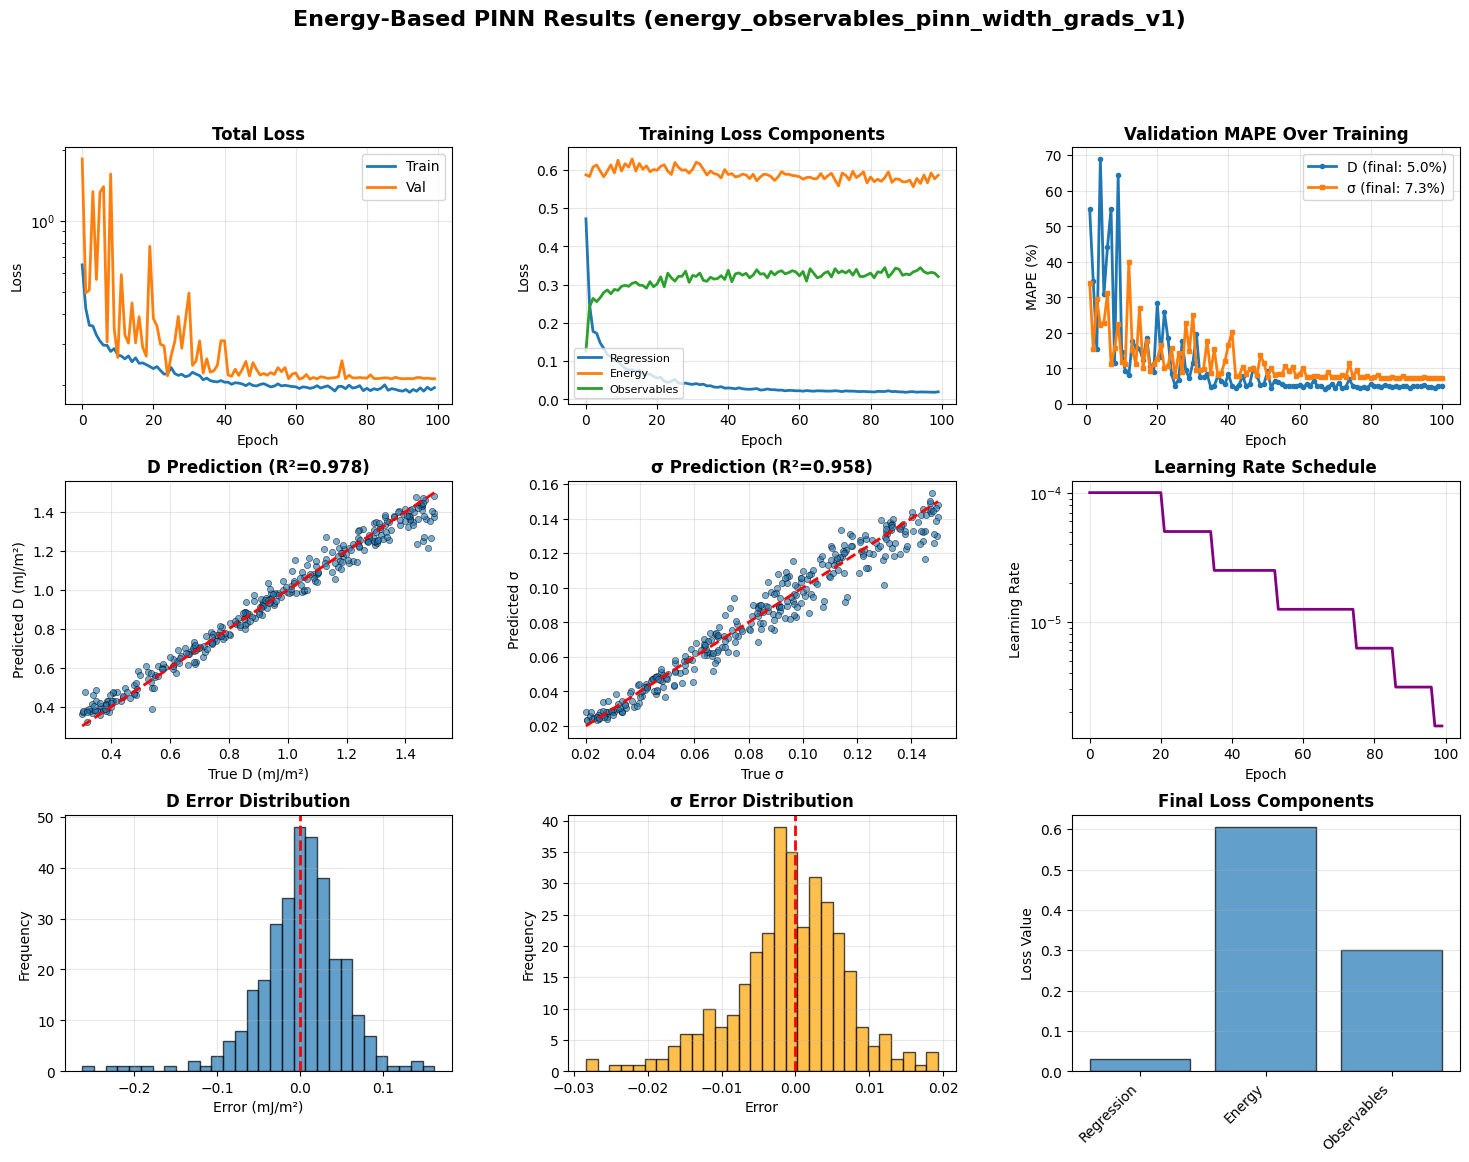


✓ Results saved to outputs_energy_FFT_pinn/energy_observables_pinn_width_grads_v1/figures/energy_pinn_results_energy_observables_pinn_width_grads_v1.png


In [194]:
# ==============================================================================
# ENERGY-BASED PINN TRAINING LOOP WITH GRADIENT TRACKING
# ==============================================================================

t_mean_t = torch.tensor(t_mean, device=device, dtype=torch.float32)
t_std_t  = torch.tensor(t_std,  device=device, dtype=torch.float32)

# Initialize gradient tracker
gradient_tracker = GradientTracker()

# Track gradients every N batches
GRAD_TRACK_INTERVAL = 10  # Track every 10 batches
batch_counter = 0

print(f"Starting Energy-Based PINN training for {EPOCHS} epochs...")
print(f"Gradient tracking enabled (every {GRAD_TRACK_INTERVAL} batches)")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):

    # ==========================
    #        TRAIN
    # ==========================
    model.train()
    
    # Track individual loss components
    running_total = 0.0
    running_reg = 0.0
    running_energy = 0.0
    running_width = 0.0
    running_obs = 0.0
    n_batches = 0

    for imgs, m_fields, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        
        # Move m_fields to device if available
        if m_fields is not None:
            m_fields = {k: v.to(device) for k, v in m_fields.items()}

        # Determine if we should track gradients this batch
        track_grads = (batch_counter % GRAD_TRACK_INTERVAL == 0)

        optimizer.zero_grad()

        if track_grads:
            # ============================================================
            # GRADIENT TRACKING MODE (no AMP for clean gradients)
            # ============================================================
            
            # Forward pass
            outputs = model(imgs)
            
            # Denormalize predictions
            params_pred = criterion.denormalize_params(outputs)
            D_pred = params_pred[:, 0]
            sigma_pred = params_pred[:, 1]
            
            # ========================================
            # Compute individual loss components
            # ========================================
            
            # 1. Regression loss
            loss_reg_comp = F.mse_loss(outputs, targets)
            
            # 2. Energy loss
            if m_fields is not None:
                mx = m_fields['mx']
                my = m_fields['my']
                mz = m_fields['mz']
                
                E_ex = compute_exchange_energy_density(
                    mx, my, mz, 
                    PHYS_PARAMS['Aex'], 
                    PHYS_PARAMS['cell_x'], 
                    PHYS_PARAMS['cell_y']
                )
                E_dmi = compute_dmi_energy_density(
                    mx, my, mz, D_pred, 
                    PHYS_PARAMS['cell_x'], 
                    PHYS_PARAMS['cell_y']
                )
                
                ratio_measured = torch.abs(E_dmi) / (torch.abs(E_ex) + 1e-10)
                Q = torch.sqrt(torch.tensor(
                    PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku'], 
                    device=device
                ))
                ratio_theory = D_pred / Q
                
                ratio_measured_norm = ratio_measured / (ratio_measured.mean() + 1e-8)
                ratio_theory_norm = ratio_theory / (ratio_theory.mean() + 1e-8)
                
                loss_energy_comp = F.mse_loss(ratio_measured_norm, ratio_theory_norm)
            else:
                loss_energy_comp = torch.tensor(0.0, device=device, requires_grad=True)
            
            # 3. Width loss (DISABLED - weight = 0)
            if m_fields is not None:
                delta_measured_px = compute_domain_wall_width(mx, my, mz, 
                                                               PHYS_PARAMS['cell_x'], 
                                                               PHYS_PARAMS['cell_y'])
                delta_measured_px = delta_measured_px / PHYS_PARAMS['cell_x']

                delta_theory = theoretical_domain_wall_width(D_pred, 
                                                             PHYS_PARAMS['Aex'], 
                                                             PHYS_PARAMS['Ku'])
                delta_theory_px = delta_theory / PHYS_PARAMS['cell_x']

                log_measured = torch.log(delta_measured_px + 1.0)
                log_theory = torch.log(delta_theory_px + 1.0)

                loss_width_comp = F.mse_loss(log_measured, log_theory)
            else:
                loss_width_comp = torch.tensor(0.0, device=device, requires_grad=True)

            # ========================================
            # 4. FFT Observable Loss (Peak Sharpness → σ)
            # ========================================
            fft_obs = compute_fft_observables(imgs, n_radial_bins=64)

            # Extract peak ratio (sharpness of spectrum)
            # More disorder (higher σ) → broader spectrum → lower peak ratio
            peak_ratio = fft_obs[:, 68]  # Index 68 is peak_ratio

            # Theoretical relationship: peak sharpness decreases with disorder
            # Empirical: peak_ratio ∝ 1/(1 + α·σ)
            sigma_norm = sigma_pred / 0.15
            ratio_theory = 1.0 / (1.0 + sigma_norm * 5.0)  # α = 5.0 (tunable)

            # Normalize both for stable training
            peak_ratio_norm = peak_ratio / (peak_ratio.mean() + 1e-8)
            ratio_theory_norm = ratio_theory / (ratio_theory.mean() + 1e-8)

            loss_obs_comp = F.mse_loss(peak_ratio_norm, ratio_theory_norm)

            # ========================================
            # COMMENTED: Correlation Observable (OLD)
            # ========================================
            # corr_obs = compute_corr_observables(imgs, n_radial_bins=64)
            # L_corr = corr_obs[:, -1]
            # sigma_norm = sigma_pred / 0.15
            # L_theory = 50.0 / (sigma_norm * 100 + 1.0)
            # L_corr_norm = L_corr / (L_corr.mean() + 1e-6)
            # L_theory_norm = L_theory / (L_theory.mean() + 1e-6)
            # loss_obs_comp = F.mse_loss(L_corr_norm, L_theory_norm)
            
            # Store components for gradient tracking
            loss_components = {
                'reg': loss_reg_comp,
                'energy': loss_energy_comp,
                'width': loss_width_comp,
                'obs': loss_obs_comp  # Now uses FFT peak ratio
            }
            
            # MODIFIED: Track gradients for each component (now returns TWO values)
            stats_raw, stats_weighted = gradient_tracker.track_component_gradients(
                model, loss_components, LOSS_WEIGHTS
            )
            
            # Now compute total loss for actual training
            optimizer.zero_grad()
            loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
            loss.backward()
            
            # Gradient clipping and step
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
        else:
            # ============================================================
            # NORMAL TRAINING MODE (with AMP)
            # ============================================================
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                loss, loss_dict = criterion(outputs, targets, m_fields, imgs)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        # Accumulate losses
        running_total += loss_dict['total']
        running_reg += loss_dict['regression']
        running_energy += loss_dict['energy']
        running_width += loss_dict['width']
        running_obs += loss_dict['observables']
        n_batches += 1
        batch_counter += 1

    # Average training losses
    epoch_train_loss = running_total / n_batches
    epoch_train_reg = running_reg / n_batches
    epoch_train_energy = running_energy / n_batches
    epoch_train_width = running_width / n_batches
    epoch_train_obs = running_obs / n_batches
    
    history['train_loss_total'].append(epoch_train_loss)
    history['train_loss_reg'].append(epoch_train_reg)
    history['train_loss_energy'].append(epoch_train_energy)
    history['train_loss_width'].append(epoch_train_width)
    history['train_loss_obs'].append(epoch_train_obs)

    # ==========================
    #      VALIDATION
    # ==========================
    model.eval()
    
    running_val_total = 0.0
    running_val_reg = 0.0
    running_val_energy = 0.0
    running_val_width = 0.0
    running_val_obs = 0.0
    n_val_batches = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, m_fields, targets, run_ids in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}

            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                loss, loss_dict = criterion(outputs, targets, m_fields, imgs)

            # Accumulate validation losses
            running_val_total += loss_dict['total']
            running_val_reg += loss_dict['regression']
            running_val_energy += loss_dict['energy']
            running_val_width += loss_dict['width']
            running_val_obs += loss_dict['observables']
            n_val_batches += 1

            # Denormalize for metrics
            preds_unnorm = outputs * t_std_t + t_mean_t
            targets_unnorm = targets * t_std_t + t_mean_t

            all_preds.append(preds_unnorm.cpu())
            all_targets.append(targets_unnorm.cpu())

    # Average validation losses
    epoch_val_loss = running_val_total / n_val_batches
    epoch_val_reg = running_val_reg / n_val_batches
    epoch_val_energy = running_val_energy / n_val_batches
    epoch_val_width = running_val_width / n_val_batches
    epoch_val_obs = running_val_obs / n_val_batches
    
    history['val_loss_total'].append(epoch_val_loss)
    history['val_loss_reg'].append(epoch_val_reg)
    history['val_loss_energy'].append(epoch_val_energy)
    history['val_loss_width'].append(epoch_val_width)
    history['val_loss_obs'].append(epoch_val_obs)

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    # --------------------------
    # Metrics
    # --------------------------
    D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
    s_pred, s_true = all_preds[:, 1], all_targets[:, 1]

    mae_D = torch.mean(torch.abs(D_pred - D_true)).item()
    rmse_D = torch.sqrt(torch.mean((D_pred - D_true)**2)).item()
    mape_D = torch.mean(torch.abs((D_pred - D_true)/(D_true + 1e-10))).item() * 100

    mae_s = torch.mean(torch.abs(s_pred - s_true)).item()
    rmse_s = torch.sqrt(torch.mean((s_pred - s_true)**2)).item()
    mape_s = torch.mean(torch.abs((s_pred - s_true)/(s_true + 1e-10))).item() * 100
    
    # Add to history
    history['val_mape_D_history'].append(mape_D)
    history['val_mape_sigma_history'].append(mape_s)

    # ==========================
    # Scheduler & checkpoint
    # ==========================
    scheduler.step(epoch_val_loss)
    lr_now = optimizer.param_groups[0]["lr"]
    history['lr'].append(lr_now)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = model.state_dict().copy()

        torch.save({
            "model_state_dict": best_model_state,
            "target_mean": t_mean,
            "target_std": t_std,
            "epoch": epoch,
            "val_loss": epoch_val_loss,
            "val_loss_components": {
                'reg': epoch_val_reg,
                'energy': epoch_val_energy,
                'width': epoch_val_width,
                'obs': epoch_val_obs
            },
            "phys_params": PHYS_PARAMS,
            "loss_weights": LOSS_WEIGHTS,
            "history": history,
            "gradient_history": gradient_tracker.history  # Save gradient data
        }, BEST_PATH)

        saved_marker = " *"
    else:
        saved_marker = ""

    if epoch % 10 == 0 or epoch == 1 or saved_marker:
        print(
            f"Epoch {epoch:03d} | "
            f"Train {epoch_train_loss:.3e} "
            f"(R:{epoch_train_reg:.2e} E:{epoch_train_energy:.2e} W:{epoch_train_width:.2e} O:{epoch_train_obs:.2e}) | "
            f"Val {epoch_val_loss:.3e} | "
            f"D MAPE {mape_D:.1f}% | "
            f"σ MAPE {mape_s:.1f}% | "
            f"LR {lr_now:.1e}{saved_marker}"
        )

print("-" * 80)
print(f"Training complete! Best val loss: {best_val_loss:.4e}")
# MODIFIED: Update to reference new gradient history keys
print(f"Gradient samples collected: {len(gradient_tracker.history['grad_norm_reg_raw'])}")

model.load_state_dict(best_model_state)
print("Best model restored.")

# ==========================
# Recompute predictions with BEST model
# ==========================
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, m_fields, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)

        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets * t_std_t + t_mean_t

        all_preds.append(preds_unnorm.cpu())
        all_targets.append(targets_unnorm.cpu())

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
s_pred, s_true = all_preds[:, 1], all_targets[:, 1]


# ==============================================================================
# FINAL METRICS & ENHANCED PLOTS
# ==============================================================================

def r2(y_pred, y_true):
    ss_res = torch.sum((y_true - y_pred)**2)
    ss_tot = torch.sum((y_true - torch.mean(y_true))**2)
    return (1 - ss_res / ss_tot).item()

r2_D = r2(D_pred, D_true)
r2_s = r2(s_pred, s_true)

print("\n" + "="*80)
print("FINAL VALIDATION METRICS (Energy-Based PINN)")
print("="*80)
print(f"D     → R²={r2_D:.3f}, MAE={mae_D:.4e}, RMSE={rmse_D:.4e}, MAPE={mape_D:.1f}%")
print(f"σ     → R²={r2_s:.3f}, MAE={mae_s:.4e}, RMSE={rmse_s:.4e}, MAPE={mape_s:.1f}%")
print("="*80)

# Continue with your existing plotting code...

# --------------------------
# Enhanced 6-panel plot
# --------------------------
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Total loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['train_loss_total'], label="Train", linewidth=2)
ax1.plot(history['val_loss_total'], label="Val", linewidth=2)
ax1.set_yscale("log")
ax1.set_title("Total Loss", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Loss component breakdown (training)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['train_loss_reg'], label="Regression", linewidth=2)
ax2.plot(history['train_loss_energy'], label="Energy", linewidth=2)
#ax2.plot(history['train_loss_width'], label="Width", linewidth=2)
ax2.plot(history['train_loss_obs'], label="Observables", linewidth=2)
#ax2.set_yscale("log")
ax2.set_title("Training Loss Components", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# 3. Validation MAPE
ax3 = fig.add_subplot(gs[0, 2])
epochs_array = np.arange(1, len(history['val_mape_D_history']) + 1)
ax3.plot(epochs_array, history['val_mape_D_history'], label=f'D (final: {mape_D:.1f}%)', linewidth=2, marker='o', markersize=3)
ax3.plot(epochs_array, history['val_mape_sigma_history'], label=f'σ (final: {mape_s:.1f}%)', linewidth=2, marker='s', markersize=3)
ax3.set_title("Validation MAPE Over Training", fontsize=12, fontweight='bold')
ax3.set_xlabel("Epoch")
ax3.set_ylabel("MAPE (%)")
ax3.legend()
ax3.grid(alpha=0.3)
ax3.set_ylim(bottom=0)

# 4. D prediction scatter
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(D_true * 1e3, D_pred * 1e3, s=20, alpha=0.6, edgecolors='k', linewidth=0.5)
ax4.plot([D_true.min()*1e3, D_true.max()*1e3],
         [D_true.min()*1e3, D_true.max()*1e3], "r--", linewidth=2)
ax4.set_title(f"D Prediction (R²={r2_D:.3f})", fontsize=12, fontweight='bold')
ax4.set_xlabel("True D (mJ/m²)")
ax4.set_ylabel("Predicted D (mJ/m²)")
ax4.grid(alpha=0.3)

# 5. σ prediction scatter
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(s_true, s_pred, s=20, alpha=0.6, edgecolors='k', linewidth=0.5)
ax5.plot([s_true.min(), s_true.max()],
         [s_true.min(), s_true.max()], "r--", linewidth=2)
ax5.set_title(f"σ Prediction (R²={r2_s:.3f})", fontsize=12, fontweight='bold')
ax5.set_xlabel("True σ")
ax5.set_ylabel("Predicted σ")
ax5.grid(alpha=0.3)

# 6. Learning rate schedule
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(history['lr'], linewidth=2, color='purple')
ax6.set_yscale("log")
ax6.set_title("Learning Rate Schedule", fontsize=12, fontweight='bold')
ax6.set_xlabel("Epoch")
ax6.set_ylabel("Learning Rate")
ax6.grid(alpha=0.3)

# 7. D error distribution
ax7 = fig.add_subplot(gs[2, 0])
D_error = (D_pred - D_true) * 1e3  # in mJ/m²
ax7.hist(D_error, bins=30, alpha=0.7, edgecolor='black')
ax7.axvline(0, color='r', linestyle='--', linewidth=2)
ax7.set_title("D Error Distribution", fontsize=12, fontweight='bold')
ax7.set_xlabel("Error (mJ/m²)")
ax7.set_ylabel("Frequency")
ax7.grid(alpha=0.3)

# 8. σ error distribution
ax8 = fig.add_subplot(gs[2, 1])
s_error = s_pred - s_true
ax8.hist(s_error, bins=30, alpha=0.7, edgecolor='black', color='orange')
ax8.axvline(0, color='r', linestyle='--', linewidth=2)
ax8.set_title("σ Error Distribution", fontsize=12, fontweight='bold')
ax8.set_xlabel("Error")
ax8.set_ylabel("Frequency")
ax8.grid(alpha=0.3)

# 9. Physics loss contribution
ax9 = fig.add_subplot(gs[2, 2])
final_losses = {
    'Regression': history['val_loss_reg'][-1],
    'Energy': history['val_loss_energy'][-1],
    #'Width': history['val_loss_width'][-1],
    'Observables': history['val_loss_obs'][-1]
}
ax9.bar(final_losses.keys(), final_losses.values(), alpha=0.7, edgecolor='black')
ax9.set_title("Final Loss Components", fontsize=12, fontweight='bold')
ax9.set_ylabel("Loss Value")
ax9.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.suptitle(f"Energy-Based PINN Results ({RUN_TAG})", fontsize=16, fontweight='bold', y=0.995)
plt.savefig(FIG_DIR / f"energy_pinn_results_{RUN_TAG}.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Results saved to {FIG_DIR / f'energy_pinn_results_{RUN_TAG}.png'}")

In [195]:
# ==============================================================================
# DUAL GRADIENT ANALYSIS PLOTS: UNWEIGHTED + WEIGHTED
# ==============================================================================

def plot_gradient_analysis(gradient_history, mode='raw', run_tag=''):
    """
    Create gradient analysis plot for either raw (unweighted) or weighted gradients.
    
    Args:
        gradient_history: Dictionary with gradient tracking data
        mode: 'raw' for unweighted or 'weighted' for weighted gradients
        run_tag: String to add to filename
    """
    
    suffix = '_raw' if mode == 'raw' else '_weighted'
    title_prefix = 'Intrinsic (Unweighted)' if mode == 'raw' else 'Weighted (Training)'
    
    fig_grad = plt.figure(figsize=(20, 12))
    gs = fig_grad.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

    steps = np.arange(len(gradient_history[f'grad_norm_reg{suffix}']))

    # Helper function for safe log scaling
    def safe_set_yscale_log(ax, data):
        """Only set log scale if data has positive values"""
        if np.any(np.array(data) > 0):
            ax.set_yscale('log')
        else:
            ax.set_ylim([0, 1e-10])

    # ==============================================================================
    # ROW 1: GRADIENT MAGNITUDE FOR EACH COMPONENT
    # ==============================================================================

    # 1. Regression Gradient Magnitude
    ax1 = fig_grad.add_subplot(gs[0, 0])
    ax1.plot(steps, gradient_history[f'grad_norm_reg{suffix}'], linewidth=1.5, color='C0', alpha=0.8)
    ax1.set_title('Regression Gradient Magnitude', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Training Step (×10)')
    ax1.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax1, gradient_history[f'grad_norm_reg{suffix}'])
    ax1.grid(alpha=0.3)
    mean_reg = np.mean(gradient_history[f'grad_norm_reg{suffix}'])
    if mean_reg > 0:
        ax1.axhline(mean_reg, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_reg:.4f}')
        ax1.legend(fontsize=9)

    # 2. Energy Gradient Magnitude
    ax2 = fig_grad.add_subplot(gs[0, 1])
    ax2.plot(steps, gradient_history[f'grad_norm_energy{suffix}'], linewidth=1.5, color='C1', alpha=0.8)
    ax2.set_title('Energy Gradient Magnitude', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Training Step (×10)')
    ax2.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax2, gradient_history[f'grad_norm_energy{suffix}'])
    ax2.grid(alpha=0.3)
    mean_energy = np.mean(gradient_history[f'grad_norm_energy{suffix}'])
    if mean_energy > 0:
        ax2.axhline(mean_energy, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_energy:.4f}')
        ax2.legend(fontsize=9)

    # 3. Width Gradient Magnitude
    ax3 = fig_grad.add_subplot(gs[0, 2])
    ax3.plot(steps, gradient_history[f'grad_norm_width{suffix}'], linewidth=1.5, color='C2', alpha=0.8)
    ax3.set_title('Width Gradient Magnitude', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Training Step (×10)')
    ax3.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax3, gradient_history[f'grad_norm_width{suffix}'])
    ax3.grid(alpha=0.3)
    mean_width = np.mean(gradient_history[f'grad_norm_width{suffix}'])
    if mean_width > 0:
        ax3.axhline(mean_width, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_width:.4f}')
        ax3.legend(fontsize=9)
    else:
        ax3.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax3.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # 4. Observables Gradient Magnitude
    ax4 = fig_grad.add_subplot(gs[0, 3])
    ax4.plot(steps, gradient_history[f'grad_norm_obs{suffix}'], linewidth=1.5, color='C3', alpha=0.8)
    ax4.set_title('Observables Gradient Magnitude', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Training Step (×10)')
    ax4.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax4, gradient_history[f'grad_norm_obs{suffix}'])
    ax4.grid(alpha=0.3)
    mean_obs = np.mean(gradient_history[f'grad_norm_obs{suffix}'])
    if mean_obs > 0:
        ax4.axhline(mean_obs, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_obs:.4f}')
        ax4.legend(fontsize=9)
    else:
        ax4.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax4.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # ==============================================================================
    # ROW 2: GRADIENT VARIANCE FOR EACH COMPONENT
    # ==============================================================================

    # 5. Regression Gradient Variance
    ax5 = fig_grad.add_subplot(gs[1, 0])
    ax5.plot(steps, gradient_history[f'grad_variance_reg{suffix}'], linewidth=1.5, color='C0', alpha=0.8)
    ax5.set_title('Regression Gradient Variance', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Training Step (×10)')
    ax5.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax5, gradient_history[f'grad_variance_reg{suffix}'])
    ax5.grid(alpha=0.3)
    mean_var_reg = np.mean(gradient_history[f'grad_variance_reg{suffix}'])
    if mean_var_reg > 0:
        ax5.axhline(mean_var_reg, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_reg:.2e}')
        ax5.legend(fontsize=9)

    # 6. Energy Gradient Variance
    ax6 = fig_grad.add_subplot(gs[1, 1])
    ax6.plot(steps, gradient_history[f'grad_variance_energy{suffix}'], linewidth=1.5, color='C1', alpha=0.8)
    ax6.set_title('Energy Gradient Variance', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Training Step (×10)')
    ax6.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax6, gradient_history[f'grad_variance_energy{suffix}'])
    ax6.grid(alpha=0.3)
    mean_var_energy = np.mean(gradient_history[f'grad_variance_energy{suffix}'])
    if mean_var_energy > 0:
        ax6.axhline(mean_var_energy, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_energy:.2e}')
        ax6.legend(fontsize=9)

    # 7. Width Gradient Variance
    ax7 = fig_grad.add_subplot(gs[1, 2])
    ax7.plot(steps, gradient_history[f'grad_variance_width{suffix}'], linewidth=1.5, color='C2', alpha=0.8)
    ax7.set_title('Width Gradient Variance', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Training Step (×10)')
    ax7.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax7, gradient_history[f'grad_variance_width{suffix}'])
    ax7.grid(alpha=0.3)
    mean_var_width = np.mean(gradient_history[f'grad_variance_width{suffix}'])
    if mean_var_width > 0:
        ax7.axhline(mean_var_width, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_width:.2e}')
        ax7.legend(fontsize=9)
    else:
        ax7.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax7.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # 8. Observables Gradient Variance
    ax8 = fig_grad.add_subplot(gs[1, 3])
    ax8.plot(steps, gradient_history[f'grad_variance_obs{suffix}'], linewidth=1.5, color='C3', alpha=0.8)
    ax8.set_title('Observables Gradient Variance', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Training Step (×10)')
    ax8.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax8, gradient_history[f'grad_variance_obs{suffix}'])
    ax8.grid(alpha=0.3)
    mean_var_obs = np.mean(gradient_history[f'grad_variance_obs{suffix}'])
    if mean_var_obs > 0:
        ax8.axhline(mean_var_obs, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_obs:.2e}')
        ax8.legend(fontsize=9)
    else:
        ax8.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax8.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # ==============================================================================
    # ROW 3: COMPARATIVE ANALYSES
    # ==============================================================================

    # 9. Gradient Magnitude Comparison (Boxplots by Training Phase)
    ax9 = fig_grad.add_subplot(gs[2, 0:2])

    # Sample at early, mid, late training
    n_samples = len(steps)
    early_idx = slice(0, max(1, n_samples//10))
    mid_idx = slice(n_samples//3, max(n_samples//3 + 1, 2*n_samples//3))
    late_idx = slice(-max(1, n_samples//10), None)

    data_to_plot = []
    labels = []
    colors = []

    for name, color, key in [('Reg', 'C0', 'reg'), ('Energy', 'C1', 'energy'), 
                             ('Width', 'C2', 'width'), ('Obs', 'C3', 'obs')]:
        hist_key = f'grad_norm_{key}{suffix}'
        
        early = gradient_history[hist_key][early_idx]
        mid = gradient_history[hist_key][mid_idx]
        late = gradient_history[hist_key][late_idx]
        
        # Only add if has positive values
        if np.any(np.array(early) > 0) or np.any(np.array(mid) > 0) or np.any(np.array(late) > 0):
            data_to_plot.extend([early, mid, late])
            labels.extend([f'{name}\nEarly', f'{name}\nMid', f'{name}\nLate'])
            colors.extend([color] * 3)

    if len(data_to_plot) > 0:
        positions = np.arange(len(data_to_plot))
        bp = ax9.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, tick_labels=labels)

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax9.set_title('Gradient Magnitude Distribution Across Training Phases', fontsize=12, fontweight='bold')
        ax9.set_ylabel('Gradient L2 Norm (log scale)')
        ax9.set_yscale('log')
        ax9.grid(alpha=0.3, axis='y')
        ax9.tick_params(axis='x', rotation=45)
        plt.setp(ax9.xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        ax9.text(0.5, 0.5, 'No active gradients to display', 
                 transform=ax9.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')
        ax9.set_title('Gradient Magnitude Distribution', fontsize=12, fontweight='bold')

    # 10. Relative Gradient Contribution Over Time
    ax10 = fig_grad.add_subplot(gs[2, 2:4])

    # Compute relative contributions
    reg_norm = np.array(gradient_history[f'grad_norm_reg{suffix}'])
    energy_norm = np.array(gradient_history[f'grad_norm_energy{suffix}'])
    width_norm = np.array(gradient_history[f'grad_norm_width{suffix}'])
    obs_norm = np.array(gradient_history[f'grad_norm_obs{suffix}'])

    total_grad = reg_norm + energy_norm + width_norm + obs_norm + 1e-10

    reg_contrib = reg_norm / total_grad * 100
    energy_contrib = energy_norm / total_grad * 100
    width_contrib = width_norm / total_grad * 100
    obs_contrib = obs_norm / total_grad * 100

    # Stacked area plot
    ax10.fill_between(steps, 0, reg_contrib, label='Regression', alpha=0.7, color='C0')
    ax10.fill_between(steps, reg_contrib, reg_contrib + energy_contrib, 
                      label='Energy', alpha=0.7, color='C1')
    #ax10.fill_between(steps, reg_contrib + energy_contrib, 
    #                  reg_contrib + energy_contrib + width_contrib,
    #                  label='Width', alpha=0.7, color='C2')
    ax10.fill_between(steps, reg_contrib + energy_contrib + width_contrib,
                      reg_contrib + energy_contrib + width_contrib + obs_contrib,
                      label='Observables', alpha=0.7, color='C3')

    ax10.set_title('Relative Gradient Contribution Over Training', fontsize=12, fontweight='bold')
    ax10.set_xlabel('Training Step (×10)')
    ax10.set_ylabel('Contribution (%)')
    ax10.set_ylim([0, 100])
    ax10.legend(loc='upper right', fontsize=9)
    ax10.grid(alpha=0.3)

    plt.suptitle(f'Gradient Analysis: {title_prefix} - Physics-Informed Loss Components', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Save with appropriate filename
    filename = f'gradient_analysis_{mode}_{run_tag}.png'
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ {title_prefix} gradient analysis saved to {FIG_DIR / filename}")
    
    return reg_contrib, energy_contrib, width_contrib, obs_contrib




GENERATING DUAL GRADIENT ANALYSIS PLOTS

1. Unweighted gradients (intrinsic physics signal)...


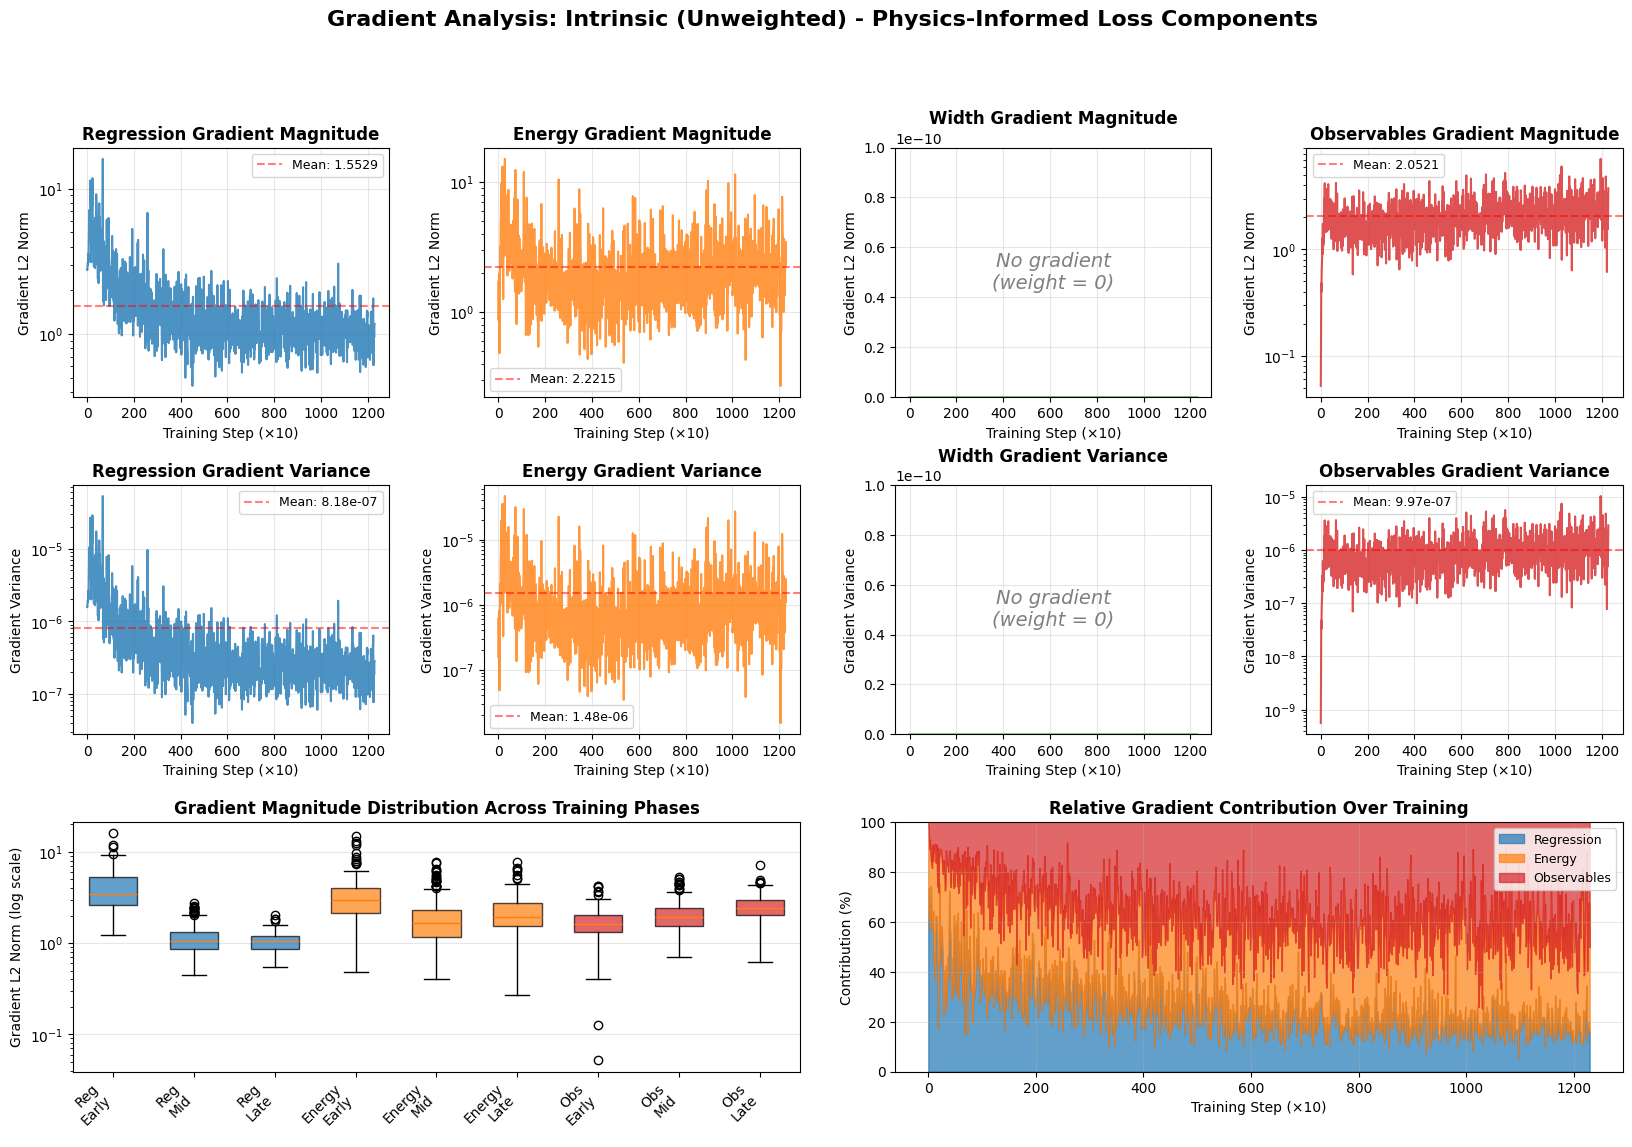


✓ Intrinsic (Unweighted) gradient analysis saved to outputs_energy_FFT_pinn/energy_observables_pinn_width_grads_v1/figures/gradient_analysis_raw_energy_observables_pinn_width_grads_v1.png

2. Weighted gradients (actual training contribution)...


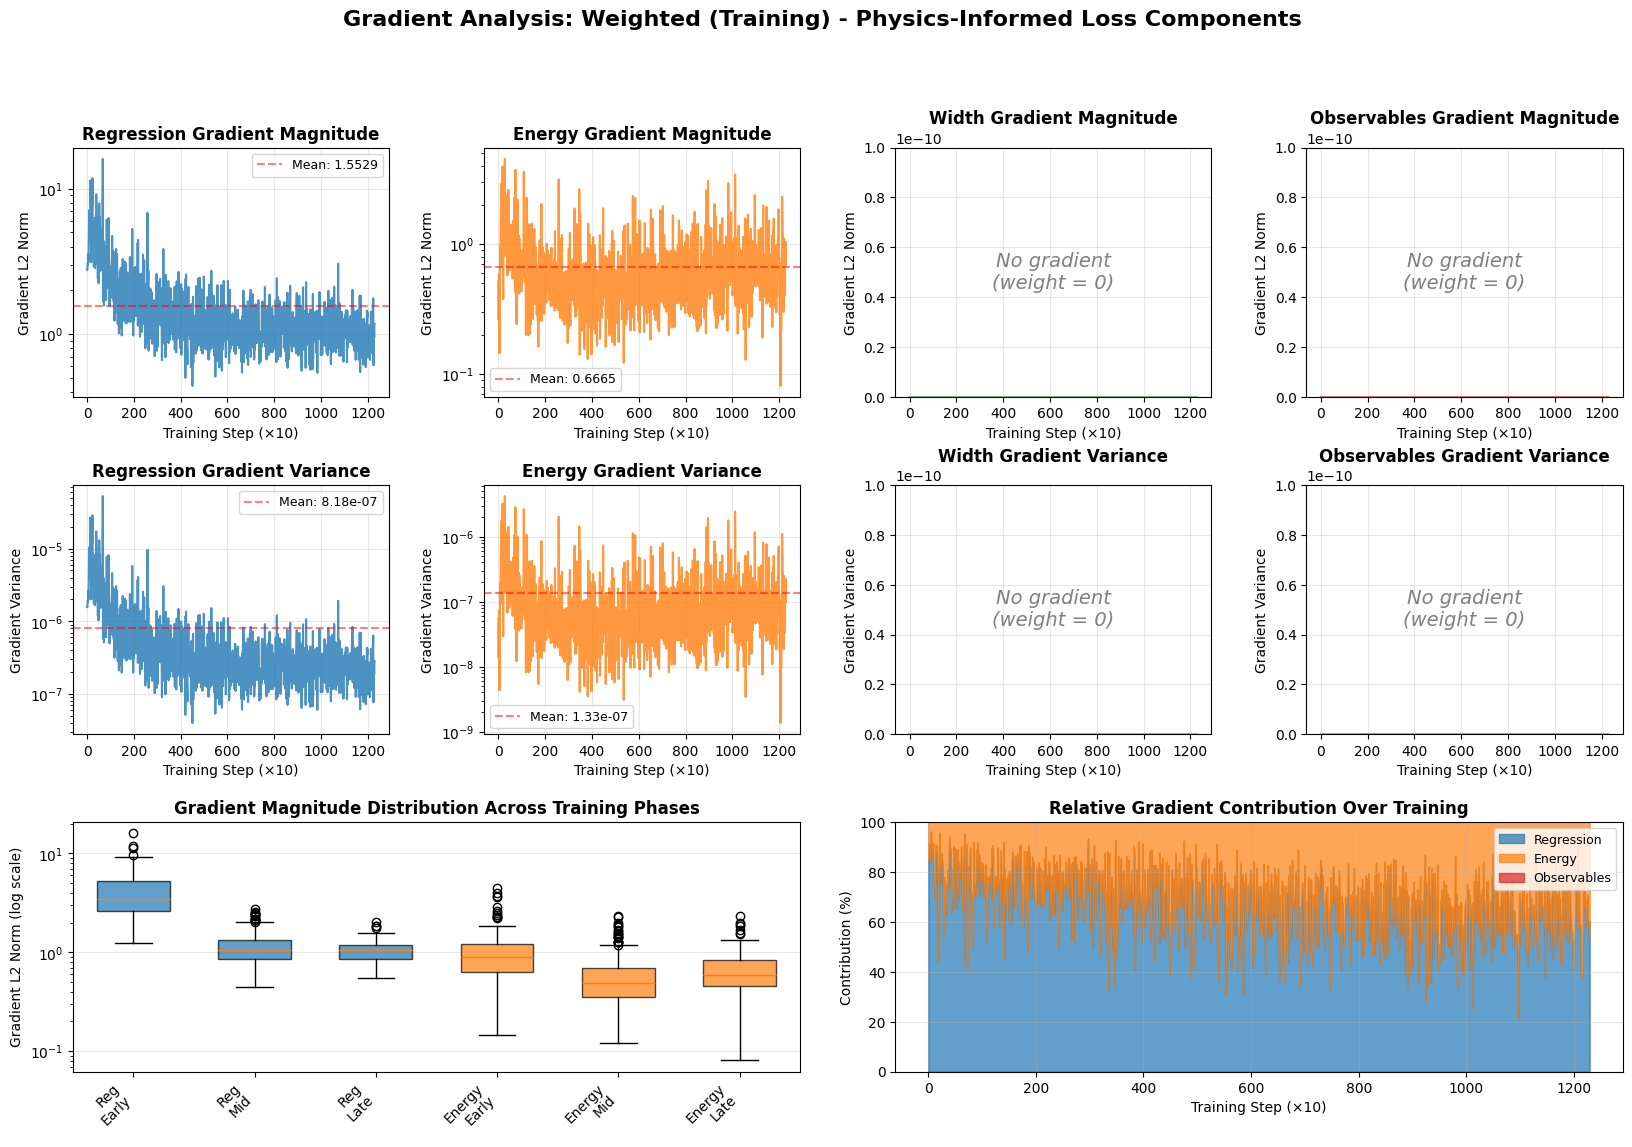


✓ Weighted (Training) gradient analysis saved to outputs_energy_FFT_pinn/energy_observables_pinn_width_grads_v1/figures/gradient_analysis_weighted_energy_observables_pinn_width_grads_v1.png

DETAILED GRADIENT STATISTICS SUMMARY

UNWEIGHTED (Intrinsic) GRADIENTS

Regression:
  Magnitude: mean=1.552931, std=1.253204, min=0.441136, max=16.017400
  Variance:  mean=8.18e-07, std=2.46e-06

Energy:
  Magnitude: mean=2.221523, std=1.504916, min=0.270654, max=15.062219
  Variance:  mean=1.48e-06, std=3.02e-06

Width: INACTIVE (no gradient)

Observables:
  Magnitude: mean=2.052124, std=0.800253, min=0.052021, max=7.118955
  Variance:  mean=9.97e-07, std=8.67e-07

--------------------------------------------------------------------------------
Average Gradient Contributions:
  Regression:   26.12% ± 11.32%
  Energy:       36.53% ± 12.37%
  Observables:  37.35% ± 12.89%

WEIGHTED (Training) GRADIENTS

Regression:
  Magnitude: mean=1.552931, std=1.253204, min=0.441136, max=16.017400
  Variance:  m

In [196]:

# ==============================================================================
# GENERATE BOTH PLOTS
# ==============================================================================

print("\n" + "="*80)
print("GENERATING DUAL GRADIENT ANALYSIS PLOTS")
print("="*80)

# 1. UNWEIGHTED (Intrinsic Physics Signal)
print("\n1. Unweighted gradients (intrinsic physics signal)...")
reg_contrib_raw, energy_contrib_raw, width_contrib_raw, obs_contrib_raw = plot_gradient_analysis(
    gradient_tracker.history, mode='raw', run_tag=RUN_TAG
)

# 2. WEIGHTED (Actual Training Contribution)
print("\n2. Weighted gradients (actual training contribution)...")
reg_contrib_weighted, energy_contrib_weighted, width_contrib_weighted, obs_contrib_weighted = plot_gradient_analysis(
    gradient_tracker.history, mode='weighted', run_tag=RUN_TAG
)


# ==============================================================================
# ENHANCED SUMMARY STATISTICS (BOTH VERSIONS)
# ==============================================================================

print("\n" + "="*80)
print("DETAILED GRADIENT STATISTICS SUMMARY")
print("="*80)

for mode, suffix in [('UNWEIGHTED (Intrinsic)', '_raw'), ('WEIGHTED (Training)', '_weighted')]:
    print(f"\n{'='*80}")
    print(f"{mode} GRADIENTS")
    print(f"{'='*80}")
    
    for name, key in [('Regression', 'reg'), ('Energy', 'energy'), ('Width', 'width'), ('Observables', 'obs')]:
        grad_norms = gradient_tracker.history[f'grad_norm_{key}{suffix}']
        grad_vars = gradient_tracker.history[f'grad_variance_{key}{suffix}']
        
        if np.any(np.array(grad_norms) > 0):
            print(f"\n{name}:")
            print(f"  Magnitude: mean={np.mean(grad_norms):.6f}, std={np.std(grad_norms):.6f}, "
                  f"min={np.min(grad_norms):.6f}, max={np.max(grad_norms):.6f}")
            print(f"  Variance:  mean={np.mean(grad_vars):.2e}, std={np.std(grad_vars):.2e}")
        else:
            print(f"\n{name}: INACTIVE (no gradient)")
    
    # Contribution percentages
    if mode == 'UNWEIGHTED (Intrinsic)':
        reg_c, energy_c, width_c, obs_c = reg_contrib_raw, energy_contrib_raw, width_contrib_raw, obs_contrib_raw
    else:
        reg_c, energy_c, width_c, obs_c = reg_contrib_weighted, energy_contrib_weighted, width_contrib_weighted, obs_contrib_weighted
    
    print("\n" + "-"*80)
    print("Average Gradient Contributions:")
    if np.mean(reg_c) > 0.01:
        print(f"  Regression:   {np.mean(reg_c):.2f}% ± {np.std(reg_c):.2f}%")
    if np.mean(energy_c) > 0.01:
        print(f"  Energy:       {np.mean(energy_c):.2f}% ± {np.std(energy_c):.2f}%")
    if np.mean(width_c) > 0.01:
        print(f"  Width:        {np.mean(width_c):.2f}% ± {np.std(width_c):.2f}%")
    if np.mean(obs_c) > 0.01:
        print(f"  Observables:  {np.mean(obs_c):.2f}% ± {np.std(obs_c):.2f}%")

print("\n" + "="*80)